## Figures 4 and 5: Model SST and Vertical Temperature Structure (Control Experiment)

**Purpose:** Generate Figures 4 and 5 of the paper.

**Description:**
Figure 4 shows (a) mean SST and (b) SST standard deviation over the Indonesian Seas and surrounding region, from the `MITgcm-RYF` Control experiment. 
The white dashed box in (a) marks the Indonesian Seas region and the black box in (b) marks the Banda Sea region.

Figure 5 shows vertical profiles of mean temperature (black) and temperature standard deviation (orange) from the same experiment, averaged 
over (a) the Indonesian Seas (white dashed box in Figure 4a) and (b) the Banda Sea (black box in Figure 4b). Blue shading highlights the 
thermocline layer, defined as the depth range with the strongest vertical temperature gradient.

**Inputs:**
- `sst_MITgcm-RYF_cntl.nc` — mean and standard deviation of SST, `MITgcm-RYF` Control experiment
- `temp_profiles_MITgcm-RYF_cntl.nc` — vertical profiles of mean and standard deviation of temperature, `MITgcm-RYF` Control experiment

In [1]:
import xarray as xr 
import numpy as np 
import pandas as pd
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
from matplotlib.patches import Rectangle
from shapely.geometry import LineString
from shapely.ops import unary_union
import regionmask
from shapely.geometry import Polygon 
from shapely.ops import unary_union
import warnings
import logging
plt.rcParams['font.size'] = 17

In [2]:
import os
os.chdir('/g/data/er50/sb4233/Scripts/Indonesian-seas-SST-variability_JGR-Oceans/') # set the path to working directory

In [3]:
warnings.filterwarnings('ignore')
mpl.rcParams['text.latex.preamble'] = r'\usepackage[utf8]{inputenc}'
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
logging.getLogger('matplotlib').setLevel(logging.ERROR)
rcParams.update({
    'text.usetex': True,            
    'font.family': 'Palatino Latino',         
    'font.serif': ['Palatino Latino'],  
    'text.latex.preamble': r'\usepackage{amsmath}'  
})

## Datasets

In [4]:
ds=xr.open_dataset('./data/sst_MITgcm-RYF_cntl.nc')
pfl=xr.open_dataset('./data/temp_profiles_MITgcm-RYF_cntl.nc')

In [5]:
# maps
mean_sst = ds.mean_sst
sd_sst   = ds.sd_sst

# profiles
pfl_mean_IS = pfl.temp_IS_mean
pfl_sd_IS   = pfl.temp_IS_sd

pfl_mean_banda = pfl.temp_banda_mean
pfl_sd_banda   = pfl.temp_banda_sd

In [6]:
polygon1 = [
    (113, -9),  # bottom-left
    (113,   0),  # top-left
    (135,   0),  # top-right
    (135, -9),  # bottom-right
]

polygon2 = [
    (117, 0),   # bottom-left
    (117,  6),  # top-left
    (127,  6),  # top-right
    (127, 0),   # bottom-right
]

poly1 = Polygon(polygon1) 
poly2 = Polygon(polygon2)
merged_poly = unary_union([poly1, poly2])
merged_coords = list(merged_poly.exterior.coords)
regions = regionmask.Regions( outlines=[merged_coords], names=["CombinedRegion"], abbrevs=["CR"], numbers=[0] )
region1 = regionmask.Regions(outlines=[polygon1])
region2 = regionmask.Regions(outlines=[polygon2])
mask1 = region1.mask(ds.XC, ds.YC)
mask2 = region2.mask(ds.XC, ds.YC)

## Figure 4:

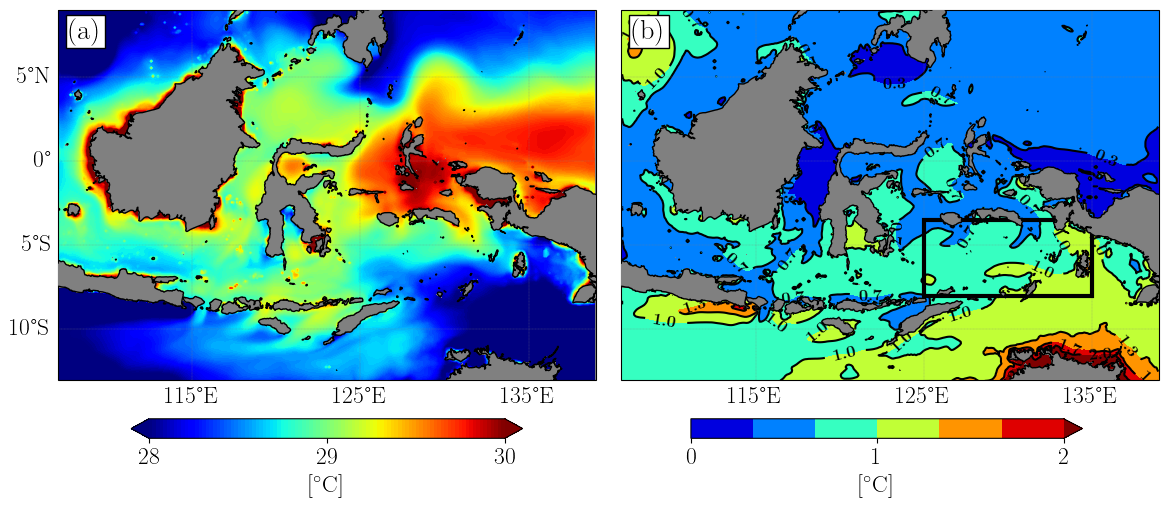

In [7]:
lats = ds.YC
lons = ds.XC

mask = mean_sst.where(mean_sst != 0) / mean_sst.where(mean_sst != 0)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# -------- (a) Mean SST --------
ax = axes[0]
cf = ax.contourf(
    lons.values, lats.values, mean_sst.where(mean_sst != 0).values,
    cmap='jet', transform=ccrs.PlateCarree(),
    levels=np.linspace(28, 30, 101), extend='both'
)
ax.set_extent([107, 139, -13, 9], crs=ccrs.PlateCarree())
ax.set_facecolor('grey')
ax.set_xlabel('Lon')
ax.set_ylabel('Lat')
gl = ax.gridlines(draw_labels=True, linestyle='--', color='grey', linewidth=0.2)
gl.xlocator = mticker.FixedLocator([115, 125, 135])
gl.ylocator = mticker.FixedLocator([-10, -5, 0, 5])
gl.top_labels = False
gl.right_labels = False
ax.coastlines(resolution='10m', zorder=11)
ax.add_feature(cfeature.LAND, facecolor="grey", zorder=10)

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal',
                    fraction=0.04, pad=0.08, ticks=np.linspace(28, 30, 3))
cbar.set_label(r'[$^\circ$C]')
ax.set_title(r"(a)", y=0.9, x=0.02, loc='left', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.1'), zorder=12)

# -------- (b) Variability (sd) --------
ax = axes[1]
cf = ax.contourf(
    lons.values, lats.values, sd_sst.where(sd_sst != 0).values,
    cmap='jet', transform=ccrs.PlateCarree(),
    levels=np.linspace(0, 2, 7), extend='max'
)
cs = ax.contour(
    lons.values, lats.values, sd_sst.where(sd_sst != 0).values,
    transform=ccrs.PlateCarree(),
    levels=np.linspace(0, 2, 7), colors='k'
)
ax.clabel(cs, inline=True,fmt=lambda x: fr'\textbf{{{x:.1f}}}', fontsize=12)
ax.set_extent([107, 139, -13, 9], crs=ccrs.PlateCarree())
ax.set_facecolor('grey')
ax.set_xlabel('Lon')
ax.set_ylabel('Lat')
gl = ax.gridlines(draw_labels=True, linestyle='--', color='grey', linewidth=0.2)
gl.xlocator = mticker.FixedLocator([115, 125, 135])
gl.ylocator = mticker.FixedLocator([-10, -5, 0, 5])
gl.top_labels = False
gl.right_labels = False
gl.left_labels = False
ax.coastlines(resolution='10m', zorder=11)
ax.add_feature(cfeature.LAND, facecolor="grey", zorder=10)

lon_min, lon_max = 125, 135
lat_min, lat_max = -8, -3.5

rect = Rectangle(
    (lon_min, lat_min),
    lon_max - lon_min,
    lat_max - lat_min,
    fill=False,
    edgecolor="k",
    linewidth=3,
    linestyle="-",
    transform=ccrs.PlateCarree(),
    zorder=2
)

ax.add_patch(rect)

cbar = plt.colorbar(cf, ax=ax, orientation='horizontal',
                    fraction=0.04, pad=0.08, ticks=np.linspace(0, 2, 3))
cbar.set_label(r'[$^\circ$C]')
ax.set_title(r"(b)", y=0.9, x=0.02, loc='left', bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.1'), zorder=12)
plt.tight_layout()

#plt.savefig('./figures/fig4.png', dpi=200, bbox_inches='tight', facecolor='white')

## Figure 5:

In [8]:
import numpy as np

def thermocline_depth(temp, z):
    """
    temp : 1D temperature profile
    z    : 1D depth array (same size, in meters)
    """
    T = np.asarray(temp)
    Z = np.asarray(z)

    dTdz = np.gradient(T, Z)
    idx = np.nanargmax(np.abs(dTdz))
    return Z[idx]

z_tc_IS    = thermocline_depth(pfl_mean_IS, pfl_mean_IS.Z)
z_tc_banda = thermocline_depth(pfl_mean_banda, pfl_mean_banda.Z)

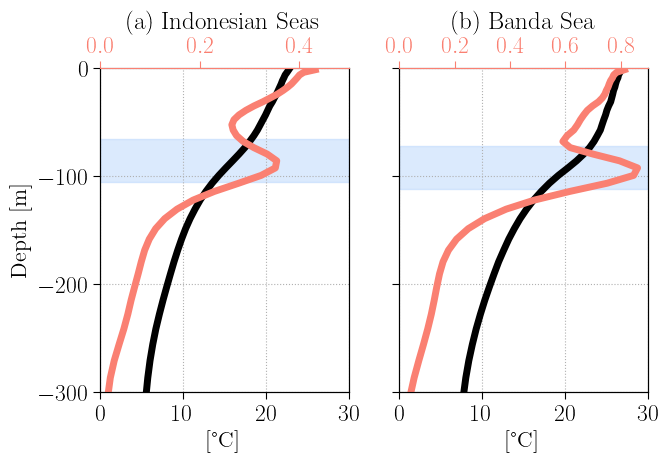

In [9]:
fig, axes = plt.subplots(1, 2,figsize=(7, 5),sharey=True)

# ------------------------------------------------------------
#  (a) Indonesian Seas Profile
# ------------------------------------------------------------
ax1 = axes[0]

ax1.plot(pfl_mean_IS, pfl_mean_IS.Z, color='k', lw=5, label=r'')
ax1.set_ylim(-300, 0)
ax1.set_yticks([-300, -200, -100, 0])
ax1.set_xlim(0, 30)
ax1.grid(ls=':')
ax1.set_xlabel('[°C]', fontsize=16)
ax1.set_ylabel('Depth [m]', fontsize=16)

ax1_twin = ax1.twiny()
ax1_twin.plot(pfl_sd_IS, pfl_sd_IS.Z, color='salmon', lw=5, label=r'')
ax1_twin.set_xlim(0, 0.5)
ax1_twin.set_xticks([0, 0.2, 0.4])
ax1_twin.tick_params(axis='x', colors='salmon')
ax1_twin.spines['top'].set_color('salmon')
ax1.tick_params(axis='both', size=5)
ax1_twin.tick_params(axis='both', size=5)

lines_main, labels_main = ax1.get_legend_handles_labels()
lines_twin, labels_twin = ax1_twin.get_legend_handles_labels()
ax1.legend(
    lines_main + lines_twin,
    labels_main + labels_twin,
    loc='lower right',
    frameon=False,
    fontsize=13
)

ax1.set_title("(a) Indonesian Seas", y=1.1, fontsize=18, loc='center')


# ------------------------------------------------------------
#  (b) Banda Sea Profile
# ------------------------------------------------------------
ax2 = axes[1]

ax2.plot(pfl_mean_banda, pfl_mean_banda.Z, color='k', lw=5, label=r'$\overline{\Theta}$')
ax2.set_ylim(-300, 0)
ax2.set_xlim(0, 30)
ax2.grid(ls=':')
ax2.set_xlabel('[°C]', fontsize=16)
ax2_twin = ax2.twiny()
ax2_twin.plot(pfl_sd_banda, pfl_sd_banda.Z, color='salmon', lw=5, label=r'{\huge $\sigma$\huge$_{\Theta}$}')
ax2_twin.set_xlim(0, 0.9)
ax2_twin.set_xticks([0, 0.2, 0.4, 0.6, 0.8])
ax2_twin.tick_params(axis='x', colors='salmon')
ax2_twin.spines['top'].set_color('salmon')
ax2.set_title("(b) Banda Sea", y=1.1, fontsize=18, loc='center')

# Thermocline
dz = 20
ax1.axhspan(
    z_tc_IS - dz, z_tc_IS + dz,
    color='xkcd:powder blue', alpha=0.45, zorder=0
)

ax2.axhspan(
    z_tc_banda - dz, z_tc_banda + dz,
    color='xkcd:powder blue', alpha=0.45, zorder=0
)
ax2.tick_params(axis='both', size=5)
ax2_twin.tick_params(axis='both', size=5)

plt.tight_layout()

#plt.savefig('./figures/fig5.png', dpi=200, bbox_inches='tight', facecolor='white')